# Анализ ВР методами без учителя



## Основные материалы к работе

### [Coloab](https://colab.research.google.com/github/MVRonkin/TimeSeriesCourse/blob/main/Last/WS/08-AnomalyTSA.ipynb)

### првоерки библиотек для DeepLearning

#### Утилиты 

##### Скачивем, если их нет

In [1]:
import os
UPDATE_UTILITS = True
if UPDATE_UTILITS:
    !rm -rf utilits4tsc temp_repo
    !git clone --depth 1 https://github.com/MVRonkin/utilits4tsc.git utilits4tsc
    

Cloning into 'utilits4tsc'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 11 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 3.12 MiB | 3.14 MiB/s, done.


##### содержание

In [2]:
from utilits4tsc import *
plt_style_GOST()

from IPython.display import display, Markdown
display(Markdown(generate_toc(max_lvl=2)))

## Содержание
* [Предсказания ВР с использованием Deep Learning](#предсказания-вр-с-использованием-deep-learning)
  * [Основные материалы к работе](#основные-материалы-к-работе)
  * [Обзор DL моделей](#обзор-dl-моделей)
  * [Знакомство с объектом `NeuralForecast`](#знакомство-с-объектом-neuralforecast)
  * [Продвинутая настройка моделей NeuralForecast](#продвинутая-настройка-моделей-neuralforecast)
  * [[Foundation Models](https://arxiv.org/abs/2504.04011)](#foundation-modelshttpsarxivorgabs250404011)
  * [Session Info](#session-info)
  * [Дополнительно](#дополнительно)

### Темы в работе

|раздел | [Nixtla](https://nixtlaverse.nixtla.io/neuralforecsat/) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/)| [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|Anomaly Detection| [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/AnomalyDetection.ipynb)/[Nixtla](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/anomalydetection.html) | [Chapter 13.7](https://otexts.com/fpppy/nbs/13-practical.html#sec-missing-outliers) |



### Дополнительня литература

* [Anomaly_Detection_toolkit](https://github.com/GeneSUN/Anomaly_Detection_toolkit)
* [time-series-anomaly-detection](https://forecastegy.com/posts/time-series-anomaly-detection-python/)
* [Time Series Forecasting Using Foundation Models ](https://github.com/marcopeix/TimeSeriesForecastingUsingFoundationModels)
* [forecasting-time-series-missing-values](https://cienciadedatos.net/documentos/py46-forecasting-time-series-missing-values.html)
* [time-series-anomaly-detection](https://cienciadedatos.net/documentos/py62-time-series-anomaly-detection.html)
* [drift-detection](https://skforecast.org/latest/user_guides/drift-detection)


### Сопутствующие библиотеки и туториалы в них
* [sktime](https://www.sktime.net/en/v0.34.0/examples/07_detection_anomaly_changepoints.html)
* [aeon](https://github.com/aeon-toolkit/aeon/blob/main/examples/anomaly_detection/anomaly_detection.ipynb)


### Импорт

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [13]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [14]:
from scipy import stats
# import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss
import statsmodels.api as sm

In [15]:
from pandas.tseries.frequencies import to_offset

In [16]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [17]:
from functools import partial

### Загрузка данных

Импорт данных аналогично предыдущего урока.

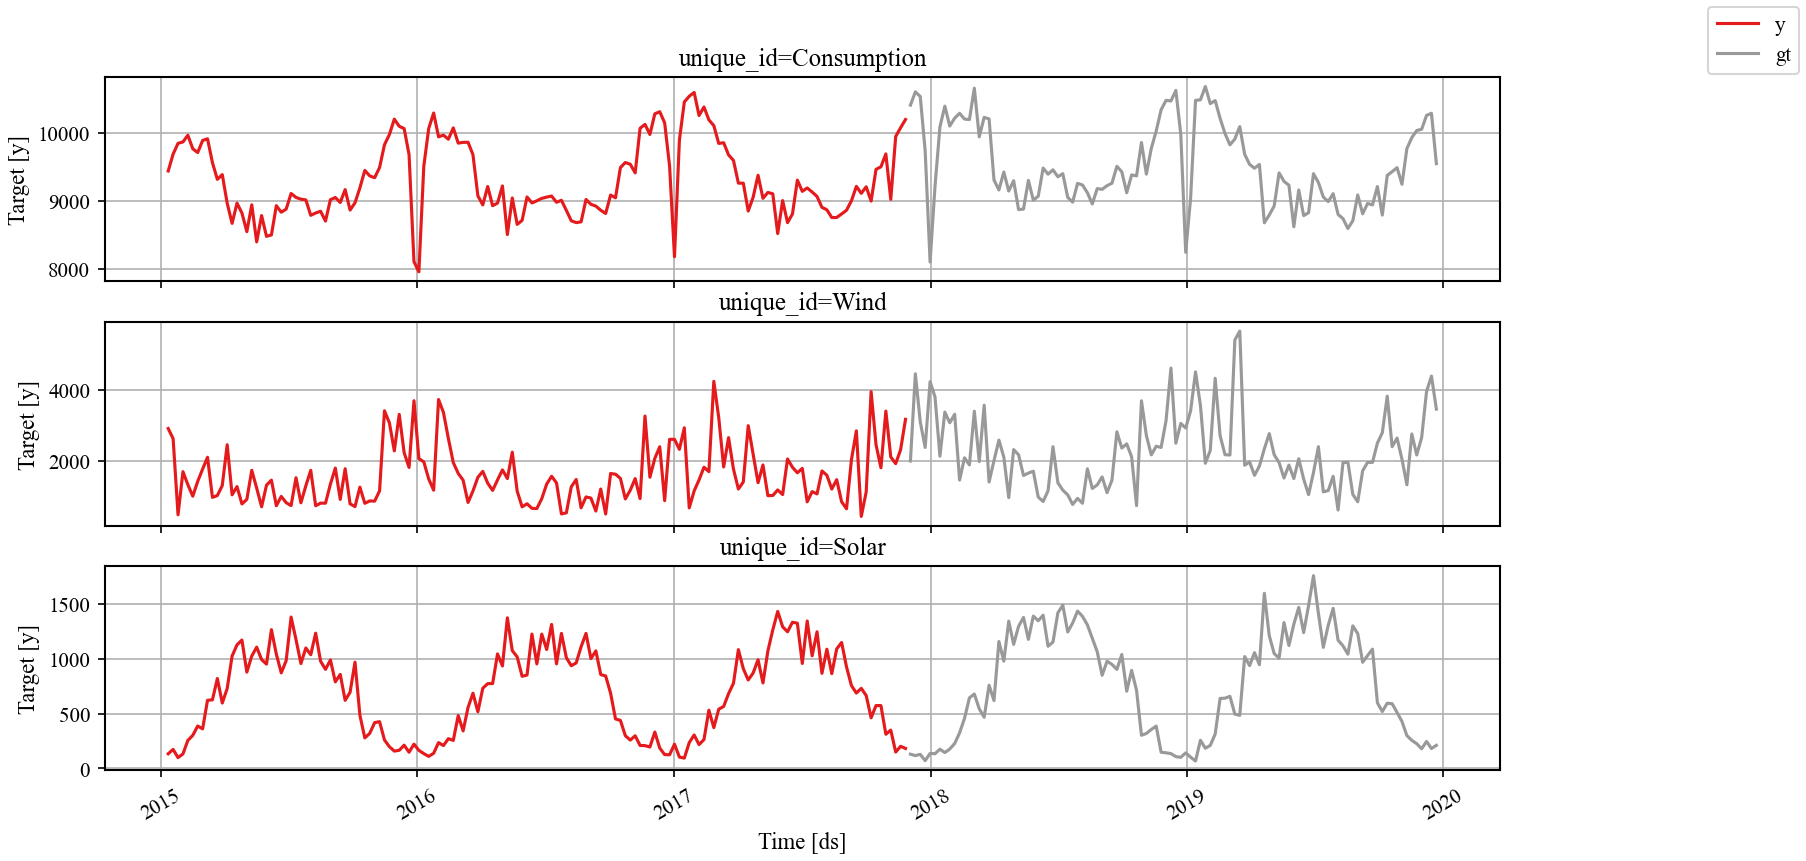

In [18]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series_v2(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1', n_cols = 1)

In [19]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    'CPSR':scaled_crps,
    'CI':coverage,
    'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Обнаружение Аномалий
<!-- ### О задачах анализа неразмеченных данных -->

<details><summary> <h3> О задачах без учителя во временных рядах</h3> </summary> 

Существует ряд задач анализа неразмечанных ВР (задачи без учителя). Среди таких наиболее расмпростроненные:
1. Поиск аномалий (редких не регулярныех событий)
2. Обнаружение новизны в данных (появление регулярного нового поведения) <img src="https://private-user-images.githubusercontent.com/15168074/492417086-35a8a193-daea-4732-9c95-11e14b8c0f30.png?jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbSIsImtleSI6ImtleTUiLCJleHAiOjE3NzM5OTE3OTgsIm5iZiI6MTc3Mzk5MTQ5OCwicGF0aCI6Ii8xNTE2ODA3NC80OTI0MTcwODYtMzVhOGExOTMtZGFlYS00NzMyLTljOTUtMTFlMTRiOGMwZjMwLnBuZz9YLUFtei1BbGdvcml0aG09QVdTNC1ITUFDLVNIQTI1NiZYLUFtei1DcmVkZW50aWFsPUFLSUFWQ09EWUxTQTUzUFFLNFpBJTJGMjAyNjAzMjAlMkZ1cy1lYXN0LTElMkZzMyUyRmF3czRfcmVxdWVzdCZYLUFtei1EYXRlPTIwMjYwMzIwVDA3MjQ1OFomWC1BbXotRXhwaXJlcz0zMDAmWC1BbXotU2lnbmF0dXJlPTcxNjhlNmVlY2FkYjRlOGNiNDYyOTAzMGNlMmEwNmNhODU4NzcwNjIwNjQxY2FhN2VmMWM2Nzg3MzIxMmJmYmYmWC1BbXotU2lnbmVkSGVhZGVycz1ob3N0In0.2aFesYHQ4Y4lgMFw3yv3zwdFUMaSPPjYcO341X1qBeY">
3. Обнаружение дрейфа данных (медленное изменение характеристик)
4. Сегментация ВР (обнаружение участков с раличным поведением ВР)
5. Обнаруженпие точек разладки (обнаружение точек смены поведения или появления новых характеристик во ВР)
   
<img src="https://raw.githubusercontent.com/sktime/sktime/53ac3f6370c2bdc6c35ddf395924ca622041537e/examples/img/annotation_tree.png" width="500px">

| Тип аномалии | Глобальные аномалии | Локальные аномалии | коллективные аномалии |
|--------|---------------------|--------------------|------------------------|
| __название__| Точечные выбросы | контекстуальные аномалии | продолжительные аномалии |
| __иллюстрация__|<img src="https://victoriametrics.com/blog/victoriametrics-anomaly-detection-handbook-chapter-2/anomaly-point.webp" width="500px">|<img src="https://victoriametrics.com/blog/victoriametrics-anomaly-detection-handbook-chapter-2/anomaly-contextual.webp" width="500px"> |<img src="https://victoriametrics.com/blog/victoriametrics-anomaly-detection-handbook-chapter-2/anomaly-collective.webp" width="500px"> |
| __пример__ | Пропуски, поломка, | нерегулярное поведение, источника данных (напр. незапланированный выходной) | возник новый шаблон поведения (напр. карантин) |



<blockquote> 

__Обратите внимание__,
* аномалии как правило неожидаются в данных, в отличии от редких, но регулярных событий, например празднечных дней.
* аномалии имеют корневые причины в источниках, прождающих данные.
* не все аномалии критичны, в каждой ситуации критерии важности аномалий нужно определять отдельно.

</blockquote>


__Для выявления аномалий во ВР__ есть несколько основных способов:
* Точки, где модель предсказания ошибается сильнее всего
* Участки, которые хуже всего восстонавливаются при сжатии-восстоновлении или при репрезенатции ВР
* Методы, основанные на машинном обучении и сведения ВР к таблицам
* Сатистичесие и проговые методы.
</details>




### Использование вероятностного предсказания для поиска аномалий

Основная идея заключается в том, что потенциальные аномалии - это точки, где модель силнее всего ошибается! Поэтому проверять их можно путем решения задачи вероятностного предсказания. Точки, или участки ВР, на которых модель ошибается и не захватывает в интервале предсказания и будут вероятными аномалиями. 

> __Обратите внимение__ модель может ошибаться и не описывать всю информацию во ВР, это может дать ложные дектирования аномалий! Лучше проверять аномалии несколькими методами!
> 

In [25]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL

#### выбор уровня доверия к данным 

In [26]:
levels = [99]

Можно проверять аномалии по нескольким уровням, чем выше уровень, тем более редкая точка - выше шанс, что она аномалия.


#### Выбор модели

In [27]:
models = [MSTL(season_length=[SEASON], alias='MSTL')]
alias = [x.alias for x in models]

Классичкеская модель MSTL предлагает разложение ВР и прогноз только трендовой и сезонной составляющих. В предыдущих занятиях модель показала себя достаточно хорошо, давая нужную точность. Также модель умеет делать интервальное предсказание (ETS). Однако, обратим внимание, что это не настоящие интервалы, а лишь их оценка из некоторых предположений о нормальности данных.

#### Обучение модели  in-sample prediction + forecast

In [28]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst = sf.forecast(df=df_train, h=FH, level=levels, fitted=True)

insample_forecasts = sf.forecast_fitted_values().drop(columns=['y'])

res_df = panel_df.merge(pd.concat([insample_forecasts,fcst],), on=['unique_id', 'ds'], how='left')


#### Выбор и визуализация аномалий
##### Встроенная визуализация аномалий по интервалу перекрытия

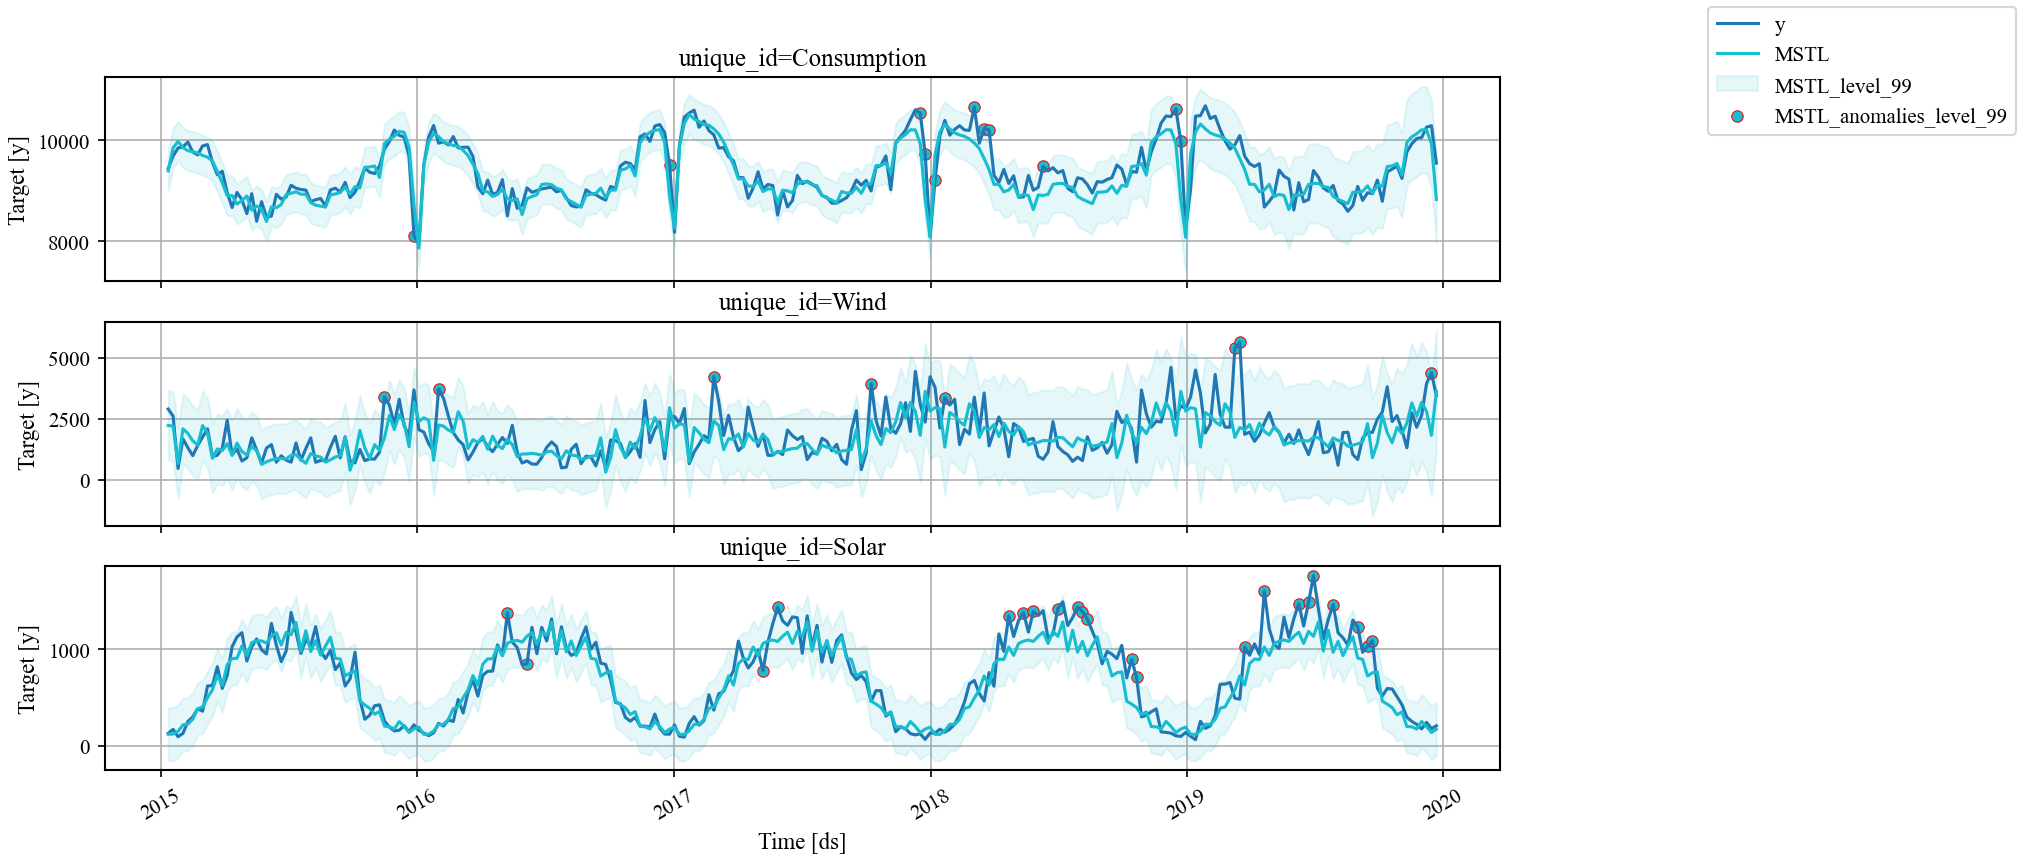

In [29]:
plot_series_v2(forecasts_df=res_df, level=levels, plot_anomalies=True)

##### Визуализация заданных аномалий

In [36]:
res_df['residual'] = res_df['y'] - res_df['MSTL']
anomalies = res_df[~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])][['unique_id', 'ds', 'y']].copy()
anomalies['MSTL_anomaly'] = 1
anomalies.head(2)

,unique_id,ds,y,MSTL_anomaly
50,Consumption,2015-12-27,8106.565,1
102,Consumption,2016-12-25,9513.222,1


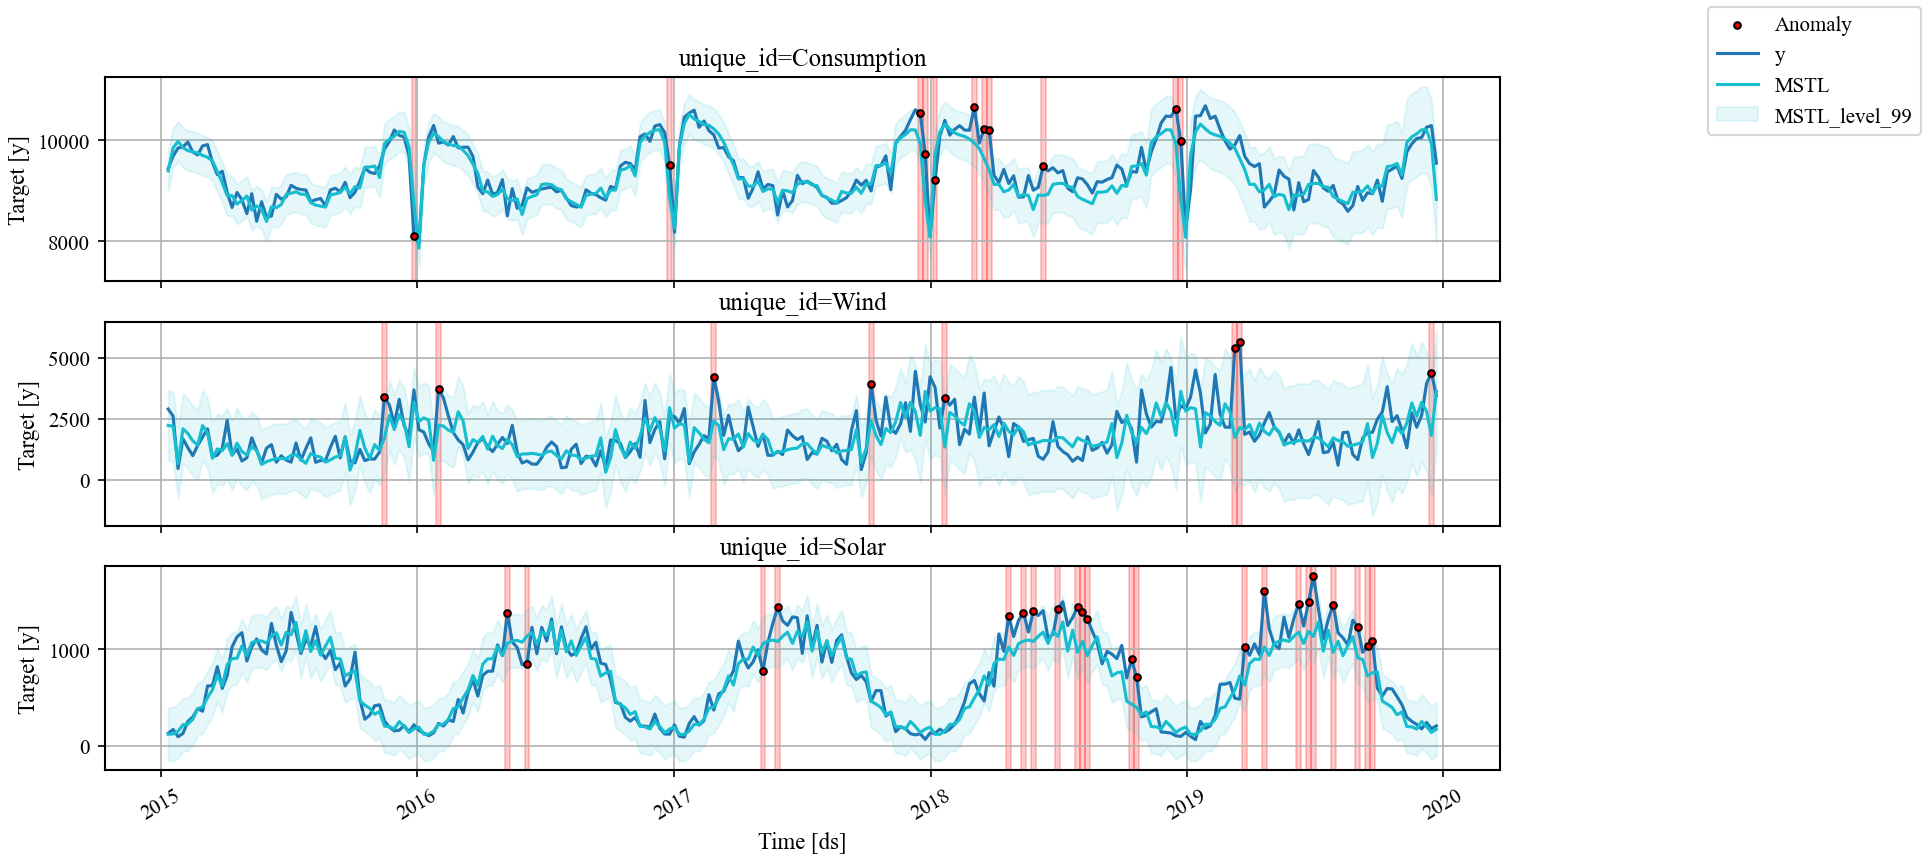

In [35]:
plot_series_v2(
    forecasts_df=res_df,
    level=levels,
    models=alias,
    anomalies_df=anomalies,
    marker_size=10,
    anomaly_width='1w',
)

Обратите внимание, что почти всегда аномалии не повторяются по датам между ВР, это может быть объяснено, например, особенностями источников данных. Однако, можно предположить, что должны быть и аномалии, характерные для отдельных да, а не только источников данных.

##### Оценка числа аномалий

Проведем оценку числа аномалий, в идеале для откалиброванного 1% интервала число точек в нем должно быть порядка 1%.

In [37]:
res_df['is_anomaly'] = ~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])

calibration = 100*res_df.groupby('unique_id')['is_anomaly'].mean()
calibration

unique_id
Consumption    4.247104
Solar          8.494208
Wind           3.088803
Name: is_anomaly, dtype: float64

Количество значений явно больше ожидаемого, однако следует проверить интервалы на калиброванность и модель на адекватное описание ВР. 

#### Проверка аномалий на гистограммах.

Проведем анализ аномалий и их сравнение с остатком модели.

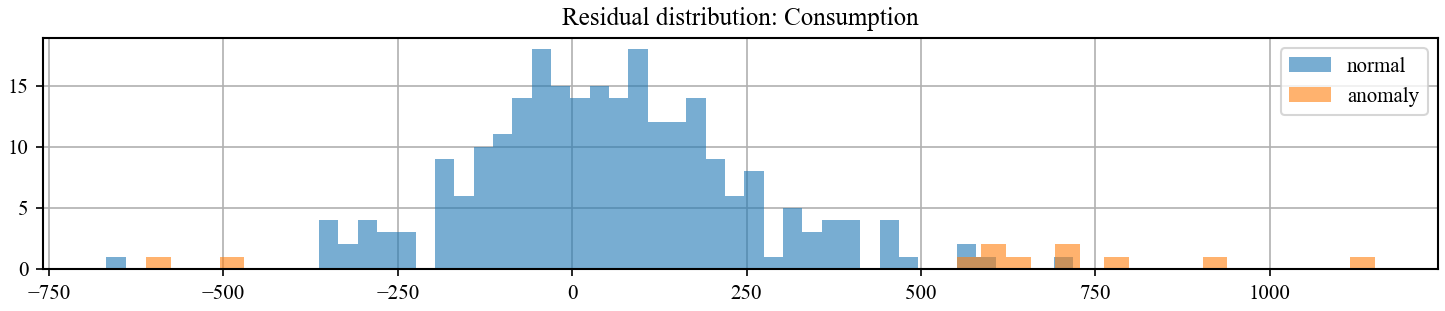

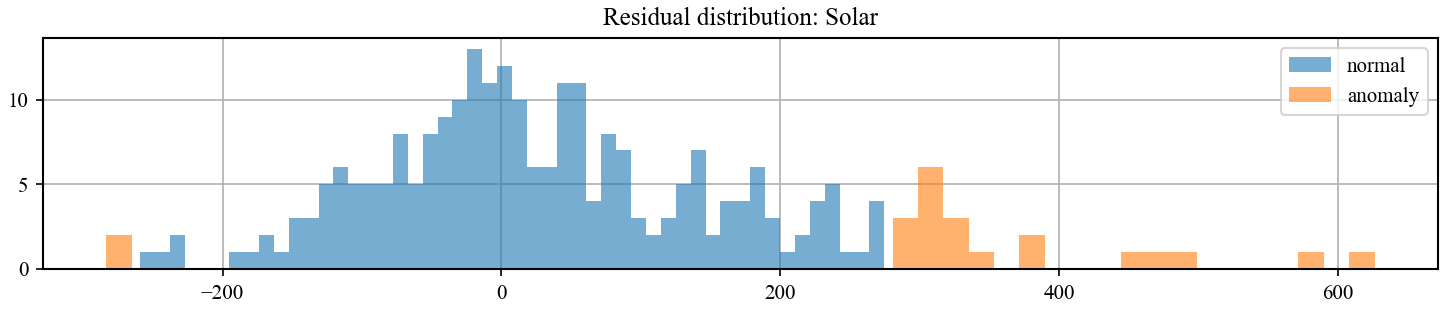

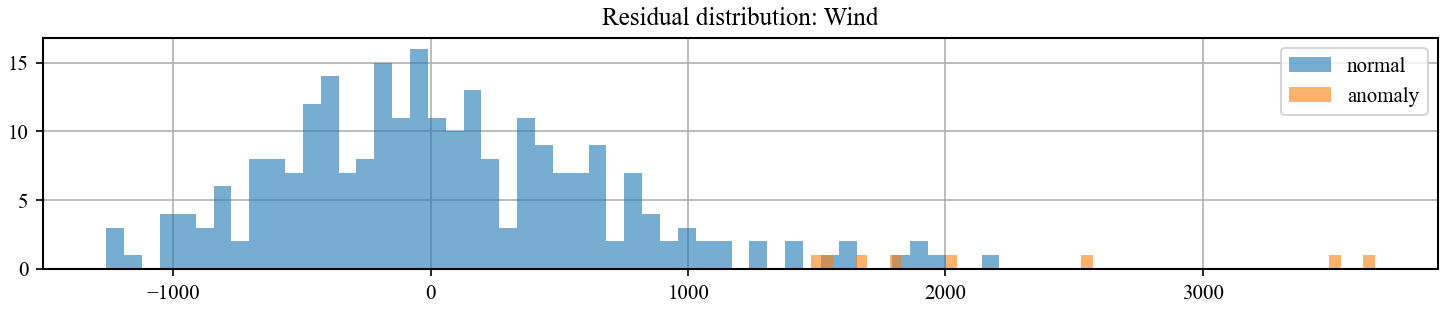

In [38]:
res_df['residual'] = res_df['y'] - res_df['MSTL']
for uid, df_uid in res_df.groupby('unique_id'):
    plt.figure(figsize = (12,2))    
    # нормальные точки
    plt.hist(df_uid[df_uid['is_anomaly']==0]['residual'], bins=50, alpha=0.6, label='normal')  
    # аномалии
    plt.hist(df_uid[df_uid['is_anomaly']==1]['residual'], bins=50, alpha=0.6, label='anomaly')
    plt.title(f"Residual distribution: {uid}")
    plt.legend()
    plt.show()

__Выводы из анализа гистограмм__:
* Поведение не однозначное, где то хвосты не определены как аномалии, а где-то аномалии внутри основной части распределений.
* Выводы могут быть как о локальном характере аномалий (это надо проверить визуально), или о том, что модель описывает не весь ВР.
* Аномалии скорее определяются с одного хвоста, что говорит о смещенности интервала покрытия моделью

#### Проверка влияни аномалий на поведение модели.

Для оценки влияния проведем анализ ACF с аномалиями и без. В случае гипотезы о влиянии мы ожидаем, что автокорреляционные лаги будут всегда завышены для аномалий?

In [31]:
from statsmodels.tsa.stattools import acf

acf_compare = []

for uid, df_uid in res_df.groupby('unique_id'):
    
    full_acf = acf(df_uid['residual'].dropna(), nlags=10)
    clean_acf = acf(df_uid[df_uid['is_anomaly']==0]['residual'].dropna(), nlags=10)
    
    acf_compare.append(pd.DataFrame({
        'lag': range(len(full_acf)),
        'acf_full': full_acf,
        'acf_clean': clean_acf,
        'unique_id': uid
    }))

acf_compare_df = pd.concat(acf_compare)
acf_compare_df.head(7)

,lag,acf_full,acf_clean,unique_id
0,0,1.000000,1.000000,Consumption
1,1,0.309817,0.200819,Consumption
2,2,0.091195,0.093536,Consumption
3,3,0.106153,0.035171,Consumption
4,4,0.020922,-0.010058,Consumption
5,5,0.053044,0.097388,Consumption
6,6,0.110387,0.187041,Consumption


Значимого изменения в поведении не вявлено.

#### Аномалии через кросс-валидацию

##### Построим n-step-ahead по удвоенному testsize

Цель - проверить метрики на фолдах с аномалиями


In [40]:
level = [99]

In [41]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
)
cv_conf = dict(h=FH//8,
           n_windows=16,
           step_size=FH//8,
           fitted = True,
           level = level,    
           refit=True,  )     

cv_df = sf.cross_validation(
    df=panel_df, 
    **cv_conf)

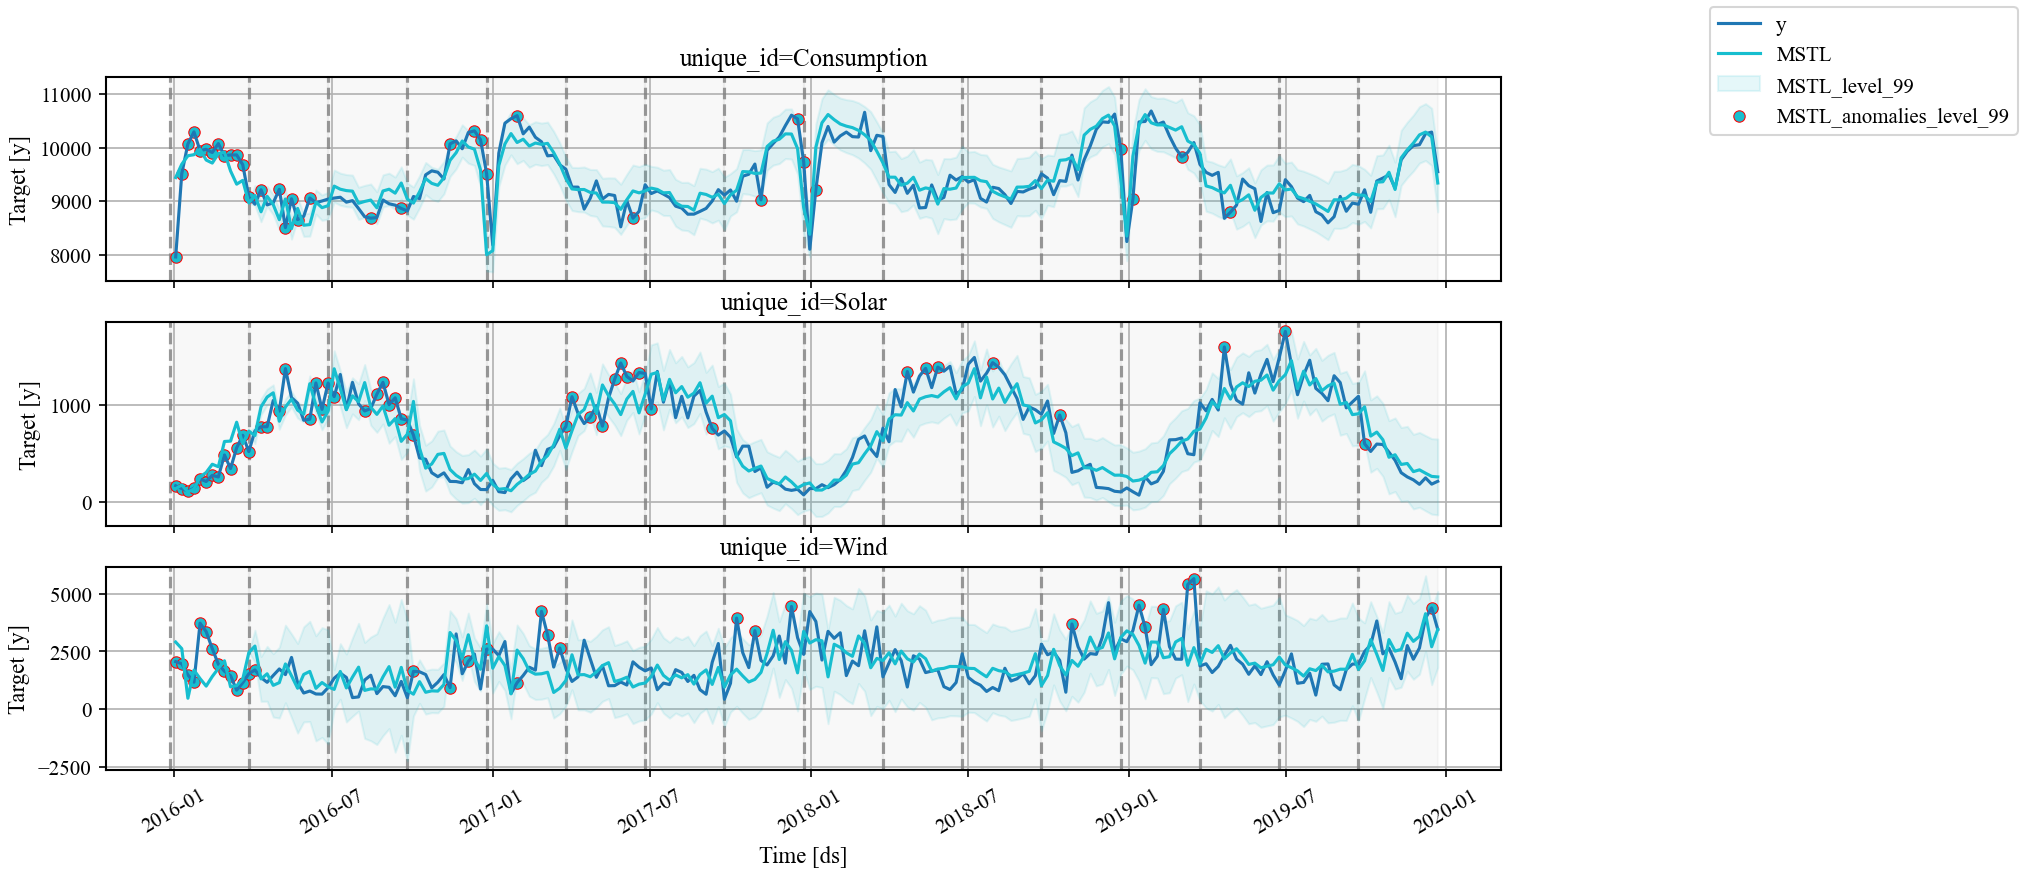

In [42]:
plot_series_v2(forecasts_df=cv_df, level=level, models = alias, plot_anomalies=True, plot_cutoff=True)

#### Оценка метрик на участках CV с аномалиями и без них

##### Посчитаем anomaly_score

In [43]:
cv_df["anomaly_score"] = np.maximum(
    cv_df["y"] - cv_df[f"{alias[0]}-hi-{level[0]}"],
    cv_df[f"{alias[0]}-lo-{level[0]}"] - cv_df["y"]
).clip(lower=0)
anomaly_grouped = cv_df.groupby(['unique_id', 'cutoff'])['anomaly_score'].mean()
# pd.DataFrame(anomaly_grouped)

##### расчет и группировка метрик

In [44]:
eval_df = evaluate(
        cv_df,
        metrics=[mae, coverage],
        level = level,    
        models = alias
    ).pivot(
    index=['unique_id', 'cutoff'], 
    columns='metric', 
    values=alias
).reset_index()
if isinstance(eval_df.columns, pd.MultiIndex):
    eval_df.columns = [f"{metric}" if metric else val for val, metric in eval_df.columns]
eval_df = eval_df.merge(anomaly_grouped, on=['unique_id', 'cutoff'], how='left')
eval_df

,unique_id,cutoff,coverage_level99,mae,anomaly_score
0,Consumption,2015-12-27,0.000000,324.603308,324.603308
1,Consumption,2016-03-27,0.538462,273.745897,122.933908
2,Consumption,2016-06-26,0.846154,233.202568,16.406021
3,Consumption,2016-09-25,0.692308,322.310788,116.431663
4,Consumption,2016-12-25,0.923077,199.035584,8.080178
5,Consumption,2017-03-26,0.923077,187.030189,1.976048
6,Consumption,2017-06-25,1.000000,113.351975,0.000000
7,Consumption,2017-09-24,0.769231,244.239038,40.334181
8,Consumption,2017-12-24,0.923077,316.041385,26.955755
9,Consumption,2018-03-25,1.000000,178.827605,0.000000


Как и ожидалось на участках с самым высоким anomaly_score самые высокие ошибки MAE и худшее покрытие

#### Упражнения
1. Провести анализ аномалий методом ARIMA сравнить результаты и сделать выявление аномалий по объеденению ("И")
2. Проверить аномалии с калбировкой интервалов 

### Анализ аномалий по остаткам предсакзаний


#### Визуализация остатков 

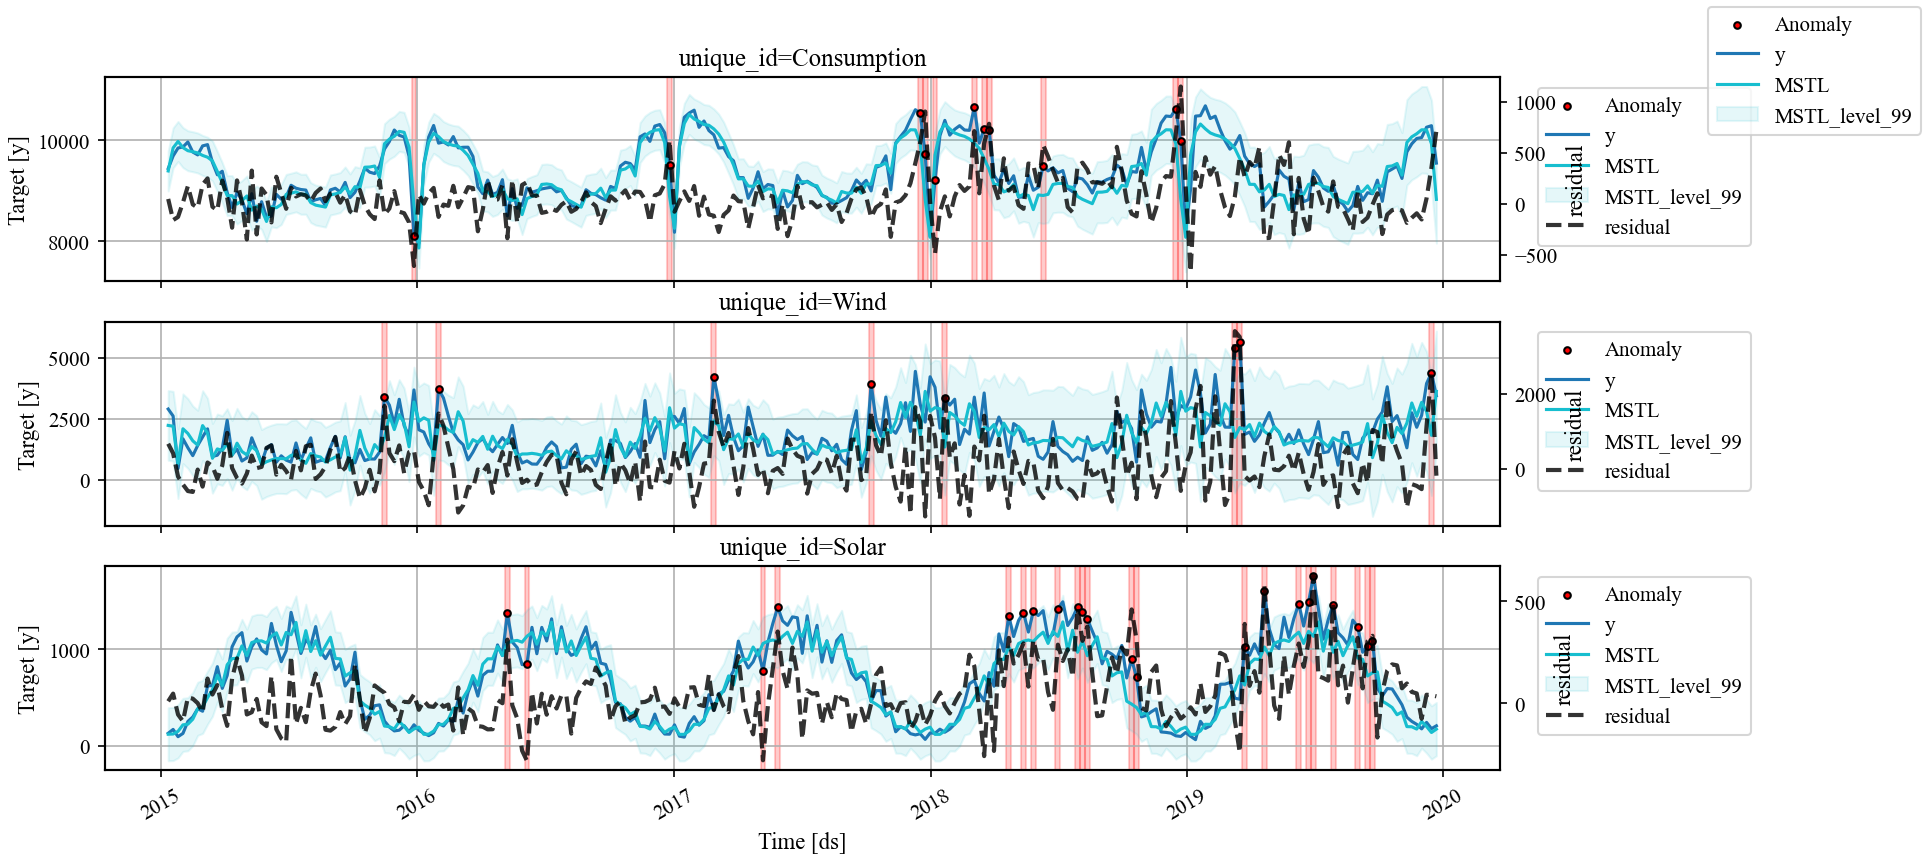

In [37]:
res_df['residual'] = res_df['y'] - res_df['MSTL']

plot_series_v2(
    forecasts_df=res_df,
    level=levels,
    models=alias,
    anomalies_df=anomalies,
    marker_size=10,
    anomaly_width='1w',
    second_axis = 'residual',
    second_axis_color = 'k'    
)

Видно, что остатки предсказания имеют наибольшее значение на аномалиях (что и ожидаемо,)

#### Статистический метод анализа остатков

Воспользуемся методом модифицированного z-score такой метод подойдет для анализа аномалий исходя из преподолжения о семетричном распределении данных не считая выбросов.

| Z score | Z modified |
|---------|------------|
| $$Z = k \cdot \frac{x - mean(x)}{std(x)}$$|$$ Z_{m} = k \cdot \frac{x - median(x)}{MAD(x)}$$|
|$k$ - ширина интервала, покрывающего нормальные данные. |$MAD(x) = meidan{|x - median(x)|}$,|
|Нормальное распределние | Распределение  с тяжелыми хвостами |
|<img width = "500px" src="https://media2.dev.to/dynamic/image/width=800%2Cheight=%2Cfit=scale-down%2Cgravity=auto%2Cformat=auto/https%3A%2F%2Fdev-to-uploads.s3.amazonaws.com%2Fuploads%2Farticles%2F9ndk9n3gqo7p6uuke7ei.png" >

* Коэфциент $k$ определяет ширину интервала, покрывающего нормальные данные $k \in [2.5,5]$ .
* Вместо $1/k$ MAD может также быть использован $IQR(x)$.
* значения моментов ($mean, var, median, mad$) могут выбираться для только нормальных данных, если они известны.
* Для нормального распределения $1.4826 \cdot meidan{|x - median(x)|} \approx \sigma $
* Для z-score нормального распределния
  * $ k=3 \to P(|Z| > 3) ≈ 0.27%$;
  * $ k=2.6 \to P(|Z| > 2.6) ≈ 1%$.

In [45]:
res_df['residual'] = res_df['y'] - res_df['MSTL']

In [49]:
def z_score_anomaly(x, k=3):
    median = np.median(x)
    mad = 1.4826 * np.median(np.abs(x - median))
    score = np.abs(x - median) / (mad + 1e-8)
    return (score > k).astype(int)

In [50]:
res_df['anomaly'] = res_df.groupby('unique_id')['residual'].transform(z_score_anomaly)
anomalies = res_df[res_df['anomaly'] >0][['unique_id', 'ds', 'y']].copy()

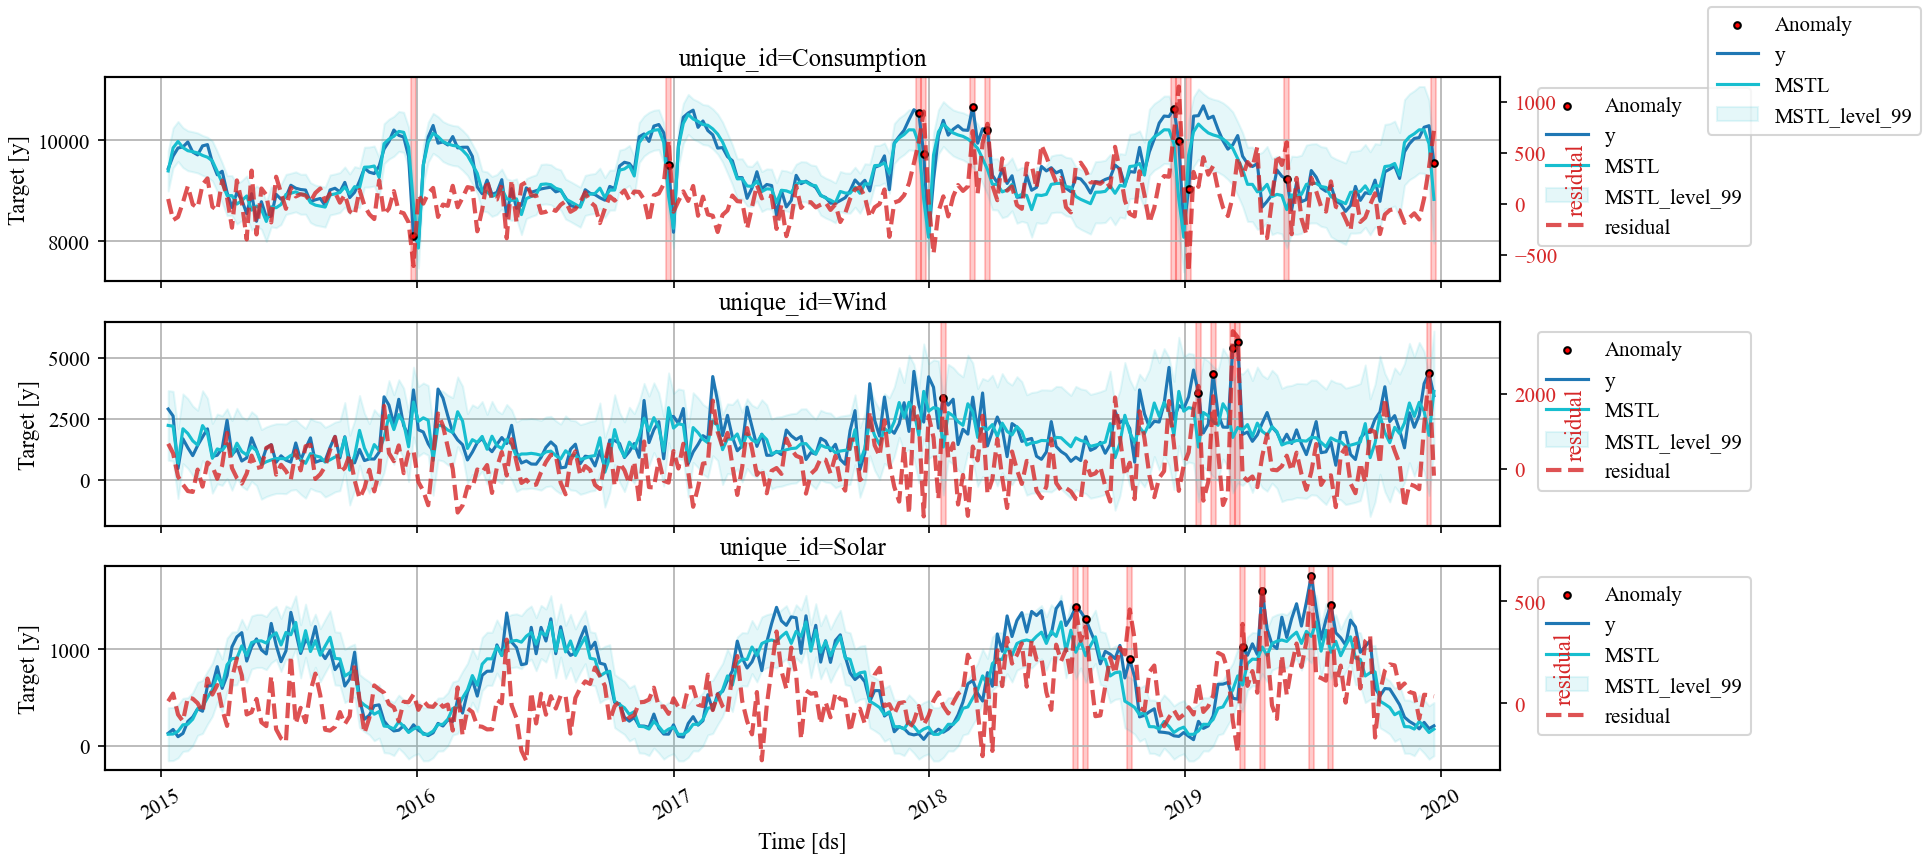

In [51]:
plot_series_v2(
    forecasts_df=res_df,
    level=levels,
    models=alias,
    anomalies_df=anomalies,
    marker_size=10,
    anomaly_width='1w',
    second_axis = 'residual'
)

В иделае медиану и MAD нужно считать на участке без аномалий

#### Упражнение:
1. Модифицировать функцию добавив режиме IRQ score и z-score
2. Провести анализ остатков на гистограммах и сравнить результаты
3. Проверить какие аномалии выделяются во всех случаях, а какие нет

### Использование Sklearn подходов и интерфейса MLForecast

#### OSVM

In [52]:
from mlforecast import MLForecast
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

OSError: dlopen(/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file)

In [ ]:
ocsvm_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('ocsvm', OneClassSVM(kernel='rbf', gamma=0.05, nu=0.01)),
])

mlf = MLForecast(
    models={'ocsvm': ocsvm_pipeline},
    freq=FREQ,
    lags=[1, 2, 3, 4, 5 ],
    # target_transforms = Di
    date_features=['week', 'month'],
)

mlf.fit(df_train, fitted=True)

# Получаем fitted values и предсказания
insample = mlf.forecast_fitted_values().drop(columns=['y'])  # ocsvm выдаёт -1/1,  
y_hat    = mlf.predict(h = FH,)
res_df   = panel_df.merge(pd.concat([insample,y_hat],), on=['unique_id', 'ds'], how='left')

# # # -1 = аномалия, 1 = норма
anomalies = res_df[res_df['ocsvm'] == -1][['unique_id', 'ds', 'y', 'ocsvm']]
# # anomalies


In [53]:
plot_series_v2(forecasts_df=res_df.drop(columns = ['ocsvm']), 
               # level=levels, 
               anomalies_df=anomalies.drop(columns = ['ocsvm']),
               marker_size = 10,
               anomaly_width = '1w'  )

KeyError: "['ocsvm'] not found in axis"

Обратим внимание, что некоторые аномалии вявлены одновременно на всех данных, что интересно.

#### Использование Unsupervised методов

In [47]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import DBSCAN, OPTICS 

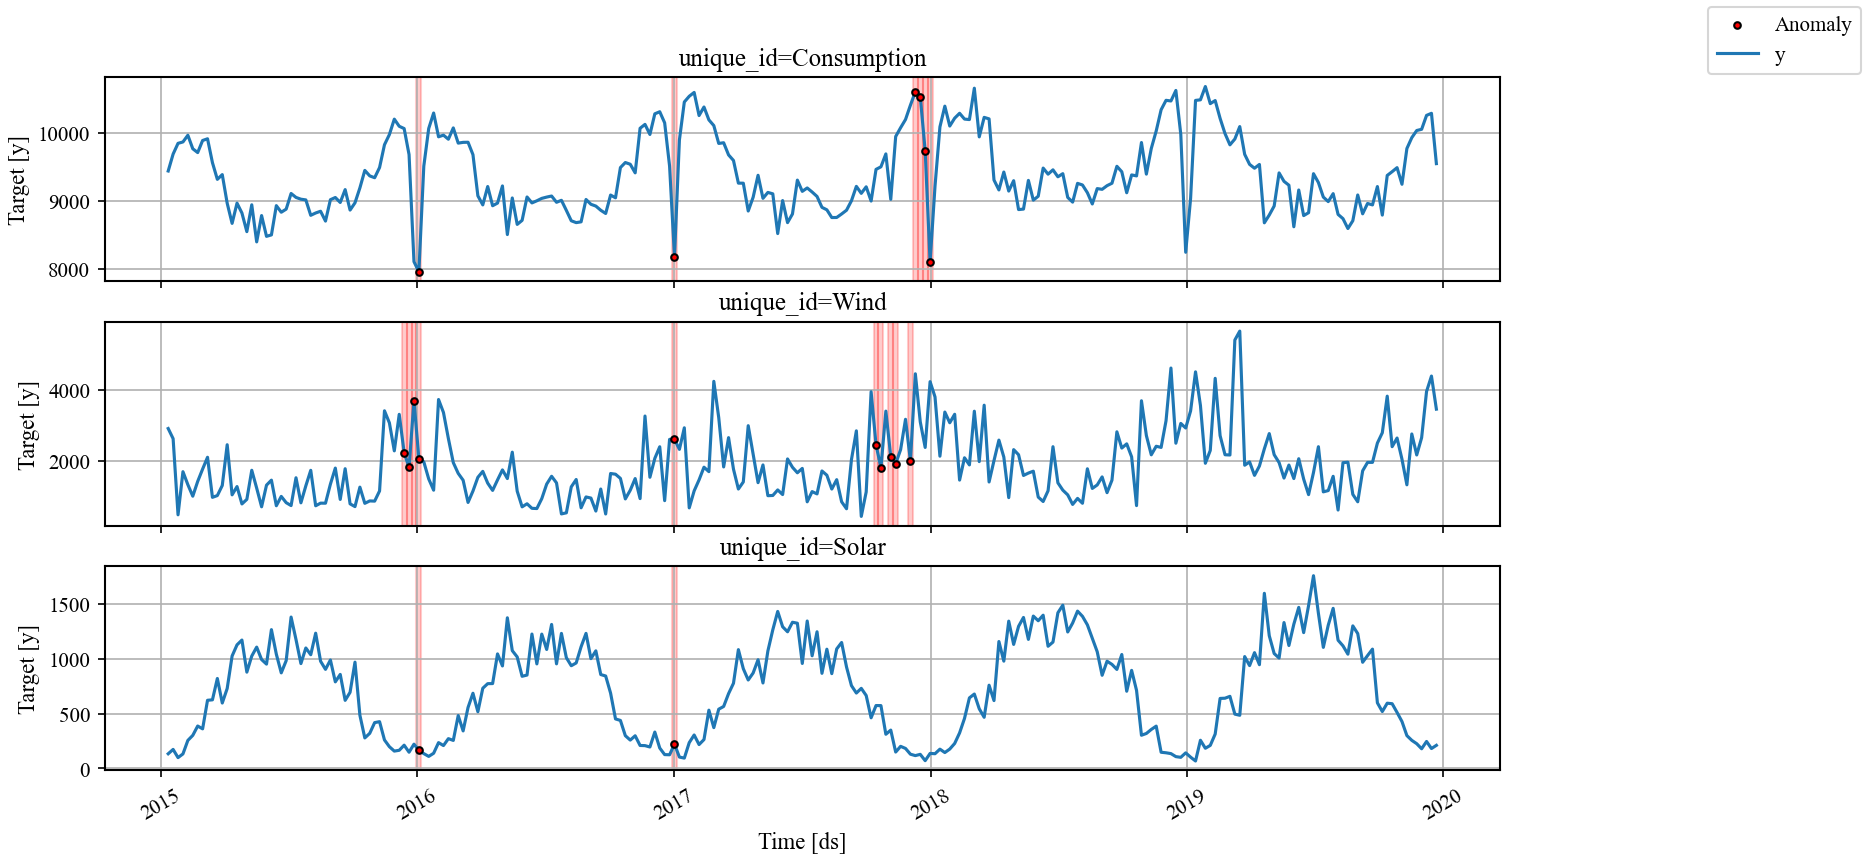

In [48]:
models_anomaly = {
    'lof': Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', LocalOutlierFactor(n_neighbors=SEASON, contamination=0.03, novelty=True)),
    ]), 
}
model_cols = list(models_anomaly.keys())

mlf = MLForecast(
    models=models_anomaly,
    freq=FREQ,
    lags=[1, 2, 3, 4,5 ],
    # target_transforms = Di
    date_features=['week', 'month'],
)

mlf.fit(df_train, fitted=True)

# Получаем fitted values и предсказания
insample = mlf.forecast_fitted_values().drop(columns=['y'])  # ocsvm выдаёт -1/1, не y_hat
y_hat    = mlf.predict(h = FH,)
res_df   = panel_df.merge(pd.concat([insample,y_hat],), on=['unique_id', 'ds'], how='left')


anomalies = res_df[
    (res_df[model_cols] == -1).any(axis=1)
].copy()

plot_series_v2(forecasts_df=res_df.drop(columns = ['lof']), 
               # level=levels, 
               anomalies_df=anomalies.drop(columns = ['lof']),
               marker_size = 10,
               anomaly_width = '1w'  )

#### Детектор основанный на правилах (вдохновлен [ADTK](https://adtk.readthedocs.io/en/stable/))

In [54]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import check_classification_targets

class QuantileAD(BaseEstimator, RegressorMixin):
    """
    Обнаружение аномалий на основе квантилей.
    Если значение выходит за пределы [low, high] квантилей, оно считается аномалией.
    """
    def __init__(self, low=None, high=None):
        self.low = low
        self.high = high
    def fit(self, X, y):
        # Проверка входных данных. X может быть пустым (dummy), y должен быть 1D массивом.
        # allow_nd=True позволяет передавать X как 2D массив, даже если мы используем только y.
        X, y = check_X_y(X, y, y_numeric=True, ensure_2d=True)        
        y_arr = np.asarray(y)        
        # Вычисляем границы
        self.abs_low_ = np.quantile(y_arr, self.low) if self.low is not None else -np.inf
        self.abs_high_ = np.quantile(y_arr, self.high) if self.high is not None else np.inf        
        # Сохраняем количество признаков для проверки в predict
        self.n_features_in_ = X.shape[1]        
        return self

    def predict(self, X):
        # Проверяем, был ли вызван fit
        check_is_fitted(self)
        # Проверяем входные данные
        X = check_array(X, ensure_2d=True)        
        # Проверка на соответствие размерности (если обучались на X с n фичами, ожидаем n)
        if X.shape[1] != self.n_features_in_:
             raise ValueError(f"Expected {self.n_features_in_} features, got {X.shape[1]}")
        # Используем первый столбец как значение ряда (lag1)
        y_arr = X[:, 0]
        return np.where((y_arr > self.abs_high_) | (y_arr < self.abs_low_), -1.0, 1.0)

In [55]:
models = {'QuantileAD': QuantileAD(low=0.1, high=0.99), }

In [56]:
mlf = MLForecast(
    models=models,
    freq=FREQ,
    lags=list(range(1,SEASON)),
    date_features=['week', 'month'],
)

mlf.fit(df_train, fitted=True)

insample = mlf.forecast_fitted_values().drop(columns=['y'])
res_df   = panel_df.merge(insample, on=['unique_id', 'ds'], how='left')

model_cols   = list(models.keys())
anomalies = res_df[
    (res_df[model_cols] == -1).any(axis=1)
].copy()


plot_series_v2(res_df, 
               anomalies_df=anomalies,               
               marker_size = 10,
               anomaly_width = '1w'  )

NameError: name 'MLForecast' is not defined

In [69]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

class AutoEncoderAD(BaseEstimator, RegressorMixin):
    def __init__(self, latent_dim=4, epochs=50, threshold_quantile=0.97):
        self.latent_dim = latent_dim
        self.epochs = epochs
        self.threshold_quantile = threshold_quantile
    
    def fit(self, X, y):
        from sklearn.neural_network import MLPRegressor
        self.ae_ = MLPRegressor(
            hidden_layer_sizes=(32, self.latent_dim, 32),
            activation='relu', max_iter=self.epochs, random_state=42
        )
        self.ae_.fit(X, X)  # учим восстанавливать вход
        reconstruction_error = np.mean((X - self.ae_.predict(X))**2, axis=1)
        self.threshold_ = np.quantile(reconstruction_error, self.threshold_quantile)
        return self
    
    def predict(self, X):
        from sklearn.utils.validation import check_is_fitted
        check_is_fitted(self)
        reconstruction_error = np.mean((X - self.ae_.predict(X))**2, axis=1)
        return np.where(reconstruction_error > self.threshold_, -1.0, 1.0)

In [71]:
mlf = MLForecast(
    models=[AutoEncoderAD()],
    freq=FREQ,
    lags=list(range(1,SEASON)),
    date_features=['week', 'month'],
)

mlf.fit(df_train, fitted=True)

insample = mlf.forecast_fitted_values().drop(columns=['y'])
res_df   = panel_df.merge(insample, on=['unique_id', 'ds'], how='left')

model_cols   = list(models.keys())
anomalies = res_df[
    (res_df[model_cols] == -1).any(axis=1)
].copy()


plot_series_v2(res_df, 
               anomalies_df=anomalies,               
               marker_size = 10,
               anomaly_width = '1w'  )

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


AttributeError: 'list' object has no attribute 'keys'

### Профилирование временного ряда

#### Понятие профиля ВР

[Matrix Profile](https://github.com/stumpy-dev/stumpy/blob/main/paper/paper.md) - метод, заключающийся в сравнении всех попарных расстояний между каждой подпоследовательностью во временном ряду (т.е. объединение по принципу самоподобия. Метод позволяет находить:
 - мотивы (повторяющиеся паттерны) 
  - диссонансы (редкие паттерны)

Метод вовзращает 2 выхода:
- profile_score это матричный профиль - то есть вектор, представляющий расстояния между всеми подпоследовательностями во временном ряду и их ближайшими соседями
    - Пики профиля: Это аномалии или уникальные паттерны. В этом месте расстояние до ближайшего похожего паттерна максимально. То есть этот участок ряда ни на что не похож.
    - Низины профиля: Это часто повторяющиеся, "нормальные" паттерны.
- profile_index (сосед) подсказывает, на что была похожа эта аномалия (иногда аномалия — это просто повтор редкого паттерна). profile_index может быть и двойным (справа и слева).

 

#### Формирование профиля

In [52]:
import stumpy
import numpy as np

In [53]:
profile_results = []
window_size = SEASON 

for uid_name, uid_df in panel_df.groupby('unique_id'):

    mp = stumpy.stump(uid_df['y'].values, m=window_size)

    # Matrix Profile сдвинут на (window_size - 1) точек
    start_idx = window_size - 1

    res_df = pd.DataFrame({
        'unique_id' : uid_name,        
        'ds': uid_df['ds'].values[start_idx:],
        'y': uid_df['y'].values[start_idx:] ,
        'profile_score': mp[:, 0], # 0-я колонка - расстояние (score)
        'profile_index': mp[:, 1],  # 1-я колонка - индекс ближайшего соседа
    })

    profile_results.append(res_df)

# Объединяем всё в один long-DataFrame
res_df = pd.concat(profile_results, ignore_index=True)


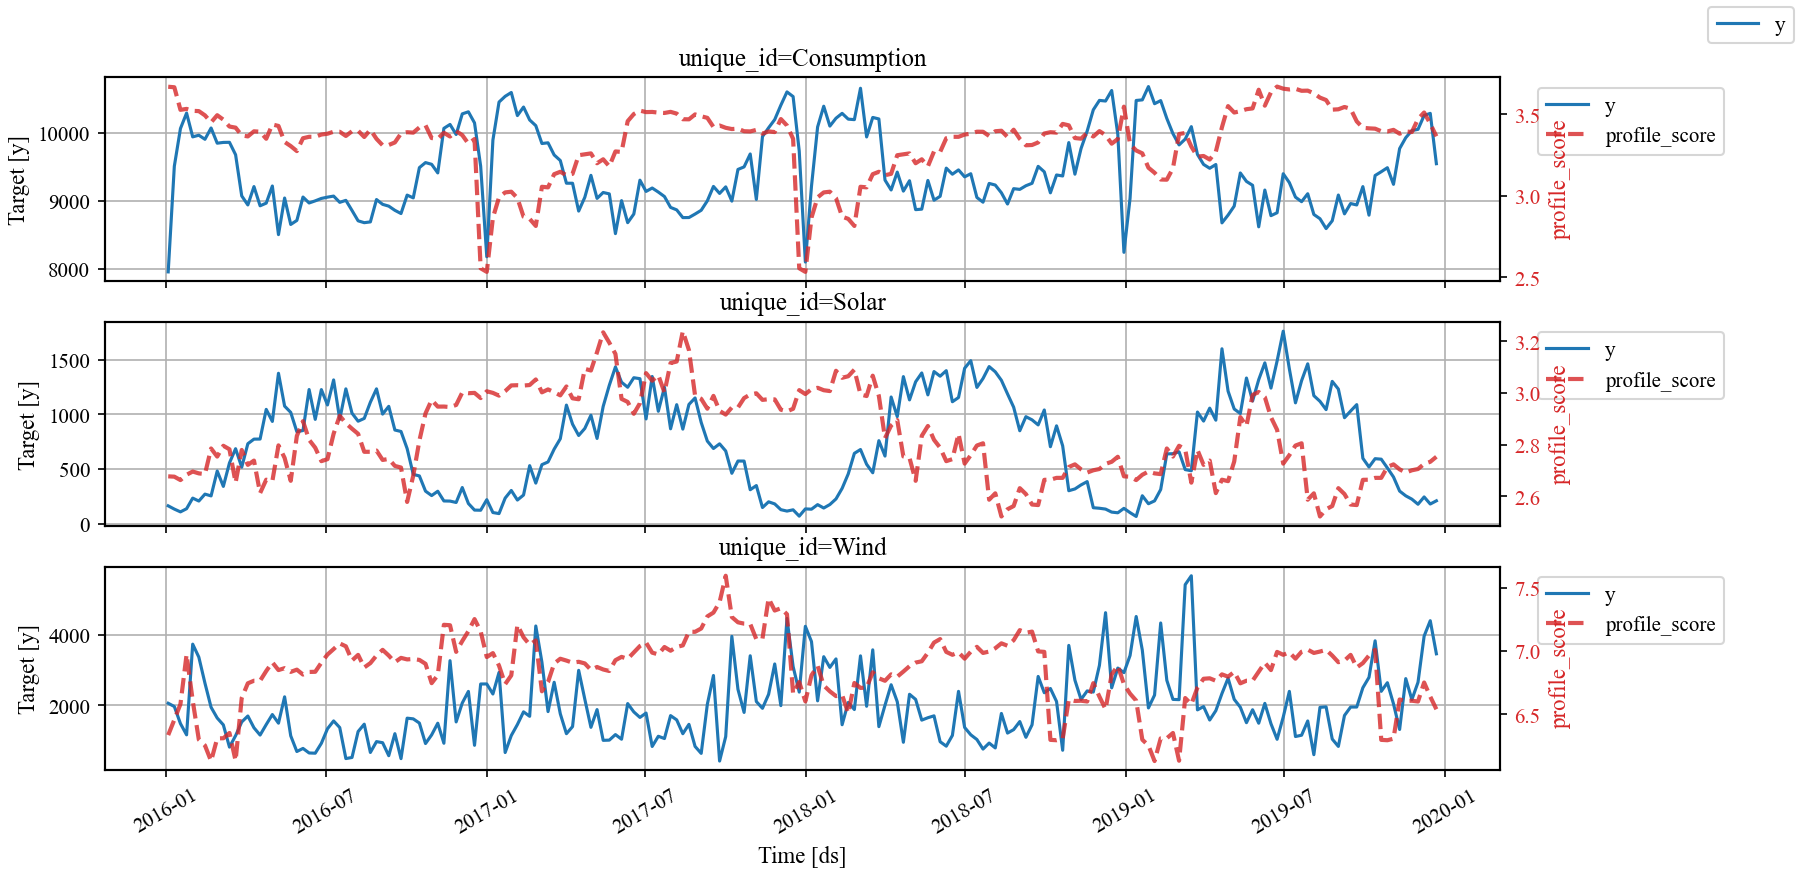

In [54]:
plot_series_v2(forecasts_df=res_df.drop(columns=['profile_index']), 
               second_axis='profile_score',
               marker_size = 10,
               anomaly_width = '1w',
          )

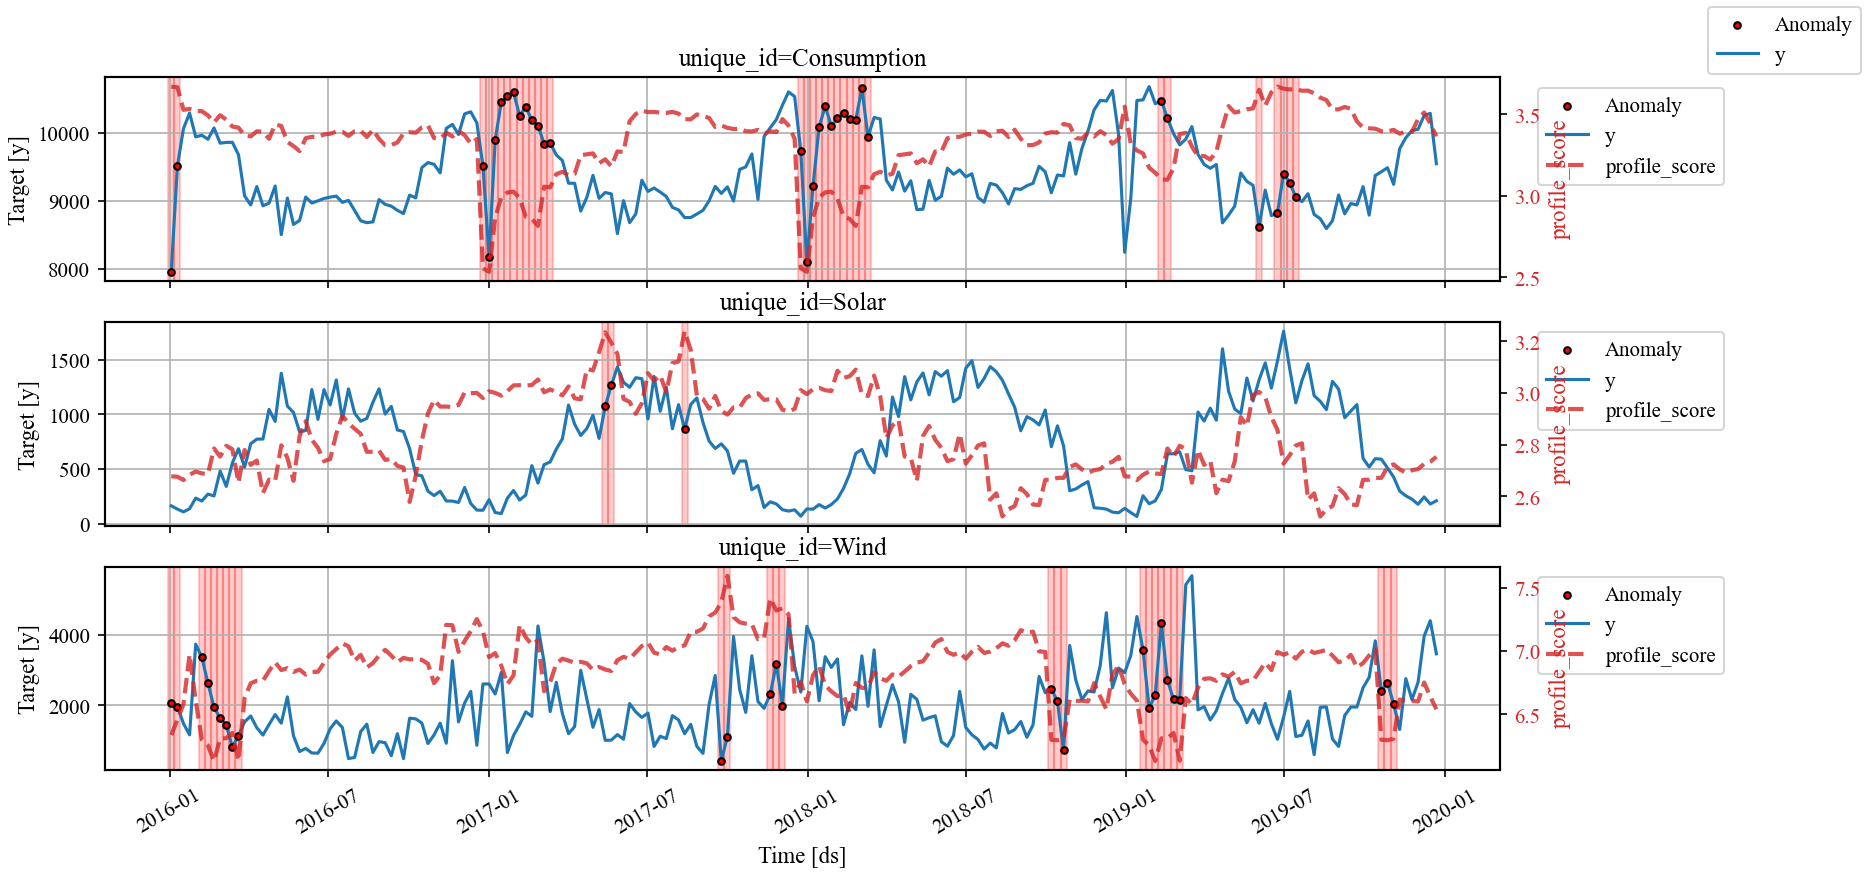

In [57]:
res_df['anomaly'] = res_df.groupby('unique_id')['profile_score'].transform(partial(z_score_anomaly, k=2.))
anomalies = res_df[res_df['anomaly'] >0][['unique_id', 'ds', 'y']].copy()

plot_series_v2(
    forecasts_df=res_df,
    anomalies_df=anomalies,
    models = [],
    marker_size=10,
    anomaly_width='1w',
    second_axis = 'profile_score'
)

#### Упражнения
1. Провести ряд искусственных искажений ВР и проверить работоспособность методв к выявлению искажений.
2. На фоне долгосрочных искажений проверить как модель АВР буде обнаруживать краткосрочные аномалии.

In [74]:
import session_info
session_info.show(html=False)

-----
aeon                1.3.0
matplotlib          3.10.8
mlforecast          1.0.3
nbformat            5.10.4
numpy               1.26.4
pandas              2.1.4
prophet             1.3.0
scipy               1.11.4
session_info        v1.0.1
sklearn             1.7.2
statsforecast       2.0.3
statsmodels         0.14.6
stumpy              Please install this project with setup.py
utilits4tsc         NA
utilsforecast       0.2.15
-----
IPython             9.10.0
jupyter_client      8.8.0
jupyter_core        5.9.1
jupyterlab          4.5.5
notebook            7.5.4
-----
Python 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
Windows-10-10.0.19045-SP0
-----
Session information updated at 2026-03-20 16:24


## Дополнительно

### AEON

#### MERLIN (Matrix profile-based discord discovery)
Метод также подпибрает профиль ВР, но 
* MERLIN автоматически подбирает оптимальную длину окна перебором,
* Для каждой длины ищет диссонанс (наиболее непохожий отрезок)
* Возвращает оценку аномальности каждой точки
Ввыход модели —  принятые решения об аномалиях.

In [65]:
from aeon.anomaly_detection.series.distance_based import STOMP, ROCKAD, MERLIN, CBLOF, KMeansAD
from aeon.anomaly_detection.series.distribution_based import DWT_MLEAD, COPOD
from aeon.anomaly_detection.series.outlier_detection import IsolationForest, STRAY
from aeon.benchmarking.metrics.anomaly_detection import range_roc_auc_score

C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\aeon\anomaly_detection\series\base.py:203: UserWarning: There is region close to constant that will cause the results to be unstable. It is suggested to delete the constant region or try again with a longer min_length.
  return self._predict(X)


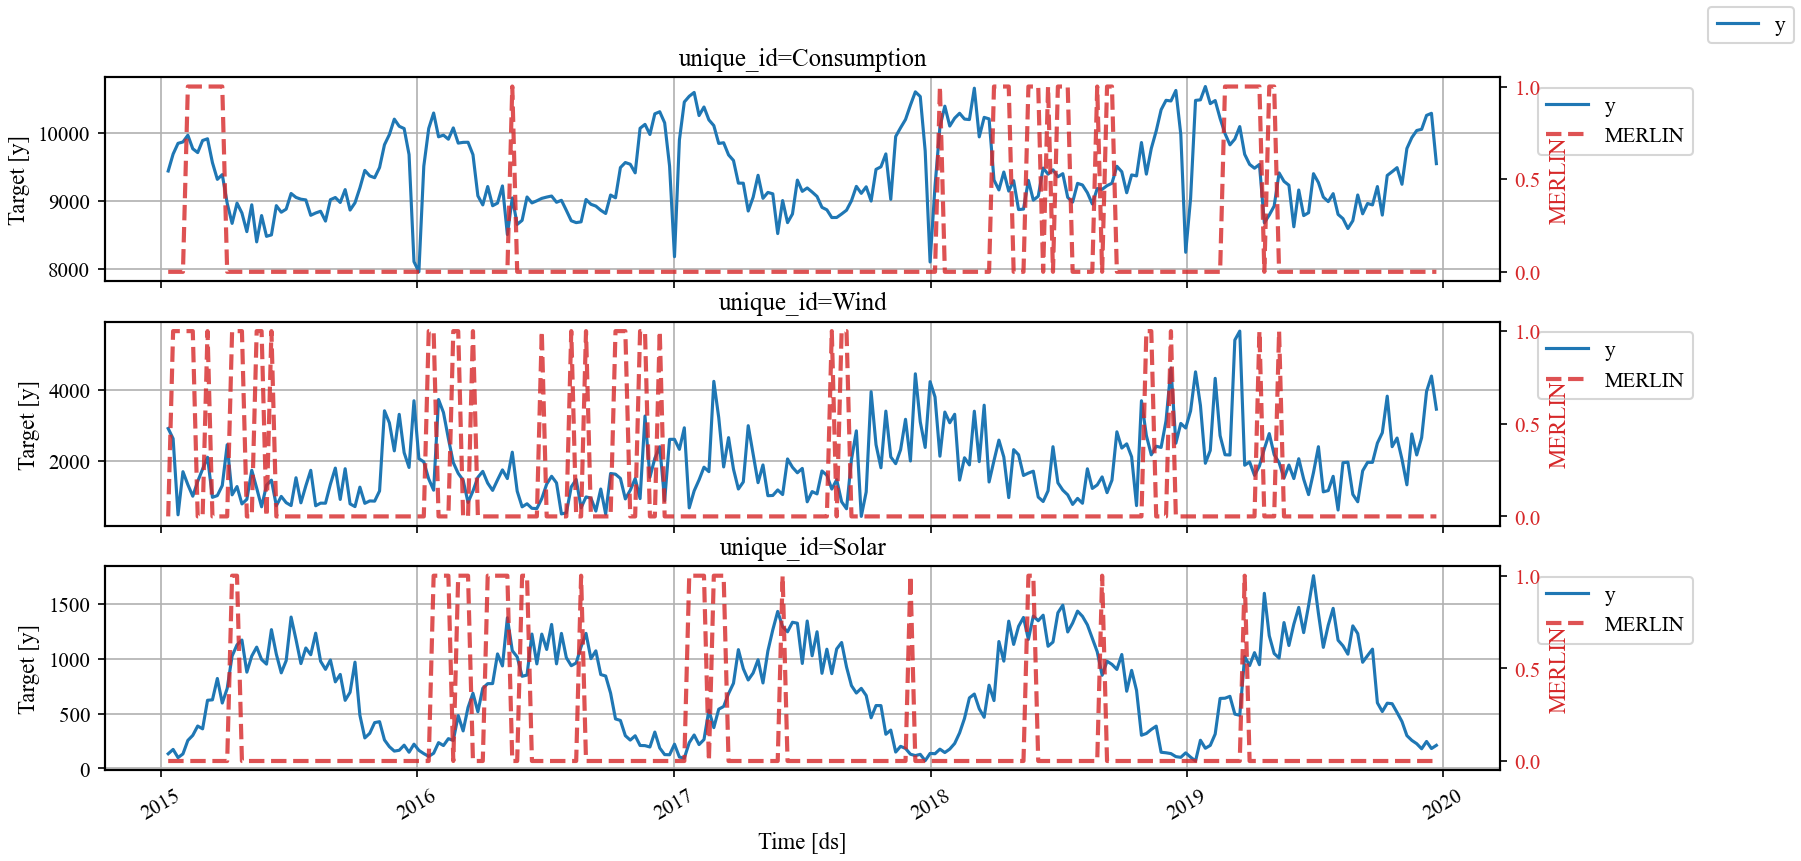

In [68]:
alies  = 'MERLIN'
results = []
for uid, df_ in panel_df.groupby("unique_id"):
    X = df_['y'].values
    detector = MERLIN(min_length=SEASON//8, max_length=SEASON, max_iterations=500)
    scores = detector.fit_predict(X)
    results.append(pd.DataFrame({        
        'unique_id': uid,
        'ds': df_['ds'],
        alies: scores
        })) 
    
anomaly_df = pd.concat(results, ignore_index=True)    
anomaly_df = panel_df.merge(
    anomaly_df[['unique_id', 'ds', alies]], 
    on=['unique_id', 'ds'], 
    how='left'
) 

plot_series_v2( forecasts_df=anomaly_df, second_axis =alies)

### Дрейф данных

Предыдущие методы искали точечные аномалии — отдельные выбросы. Но что если ряд постепенно меняет своё поведение, то  такое явление называется дрейф данных — распределение данных меняется со временем, и модель, обученная раньше, начинает описывать ряд всё хуже. 

Для обнаружения дрейфа данных можно использовать как профилирование ВР, так и более простые подходы. Основной из них строится на идеи сравнения распределений остатков в скользящем окне с референсным распределением.  

*Критерий Колмогорова–Смирнова (KS-test)** — статистический тест, проверяющий, **одинаково ли распределены** две выборки. Он не предполагает нормальности данных, что делает его универсальным.

| Результат | Интерпретация |
|-----------|---------------|
| `p_value` > `threshold` (например, 0.05) | Распределения похожи → дрейфа нет |
| `p_value` < `threshold` (например, 0.01) | Распределения значимо различаются → **дрейф обнаружен!** |

In [72]:
models = [MSTL(season_length=SEASON)]
sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst = sf.forecast(df=df_train, h=FH, level=levels, fitted=True)

insample_forecasts = sf.forecast_fitted_values().drop(columns=['y'])

res_df = panel_df.merge(pd.concat([insample_forecasts,fcst],), on=['unique_id', 'ds'], how='left')


--- Анализ дрейфа и сегментация ---


C:\Users\Ronkin\AppData\Local\Temp\ipykernel_14980\2393737011.py:29: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  stat, p_value = ks_2samp(ref_window, cur_window)


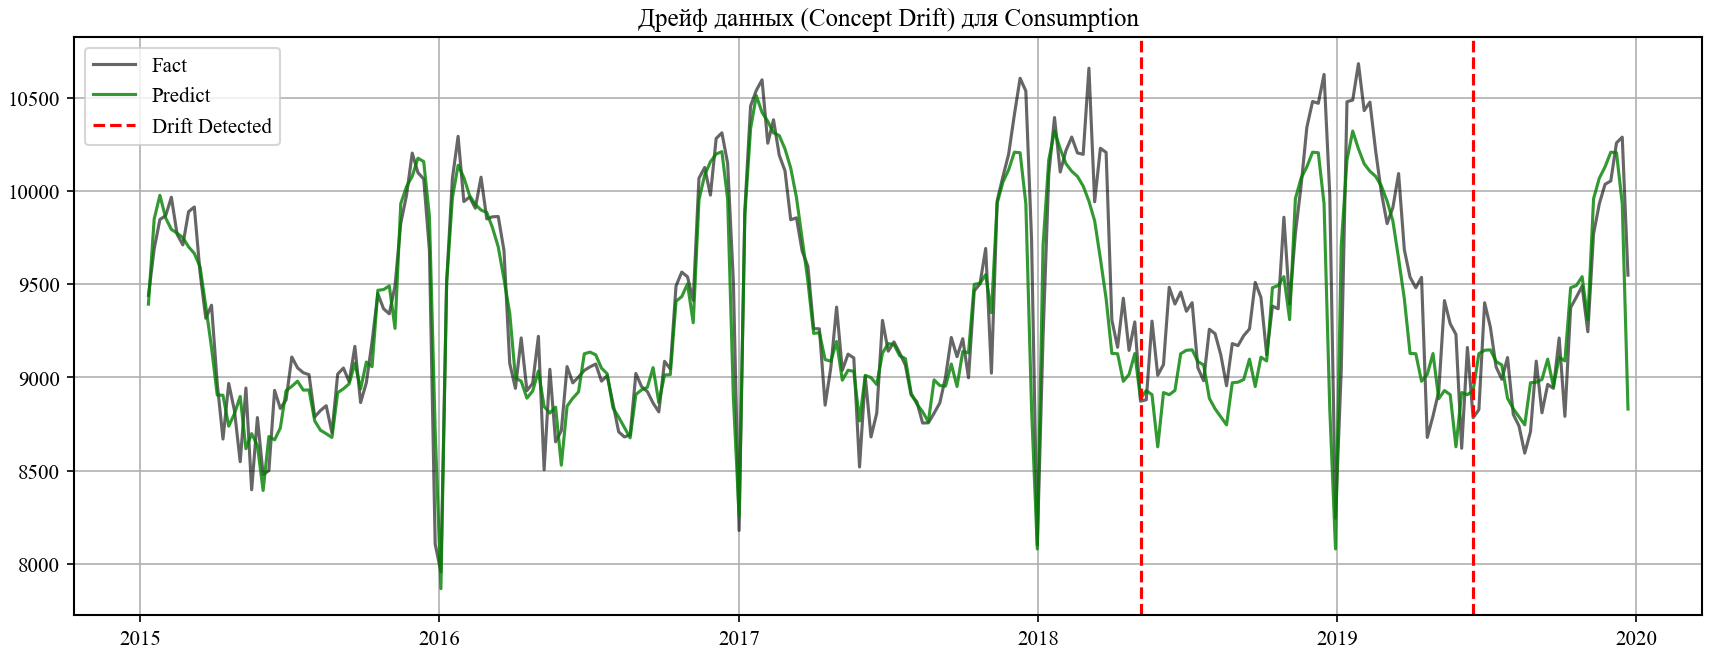

Сегменты для Consumption:


,start,end,mean_residual,std_residual,type
0,2015-01-11,2018-04-29,39.687233,197.652700,Stable
1,2018-05-06,2019-06-09,208.901997,291.200071,Stable
2,2019-06-16,2019-12-22,-20.849104,214.808654,Current


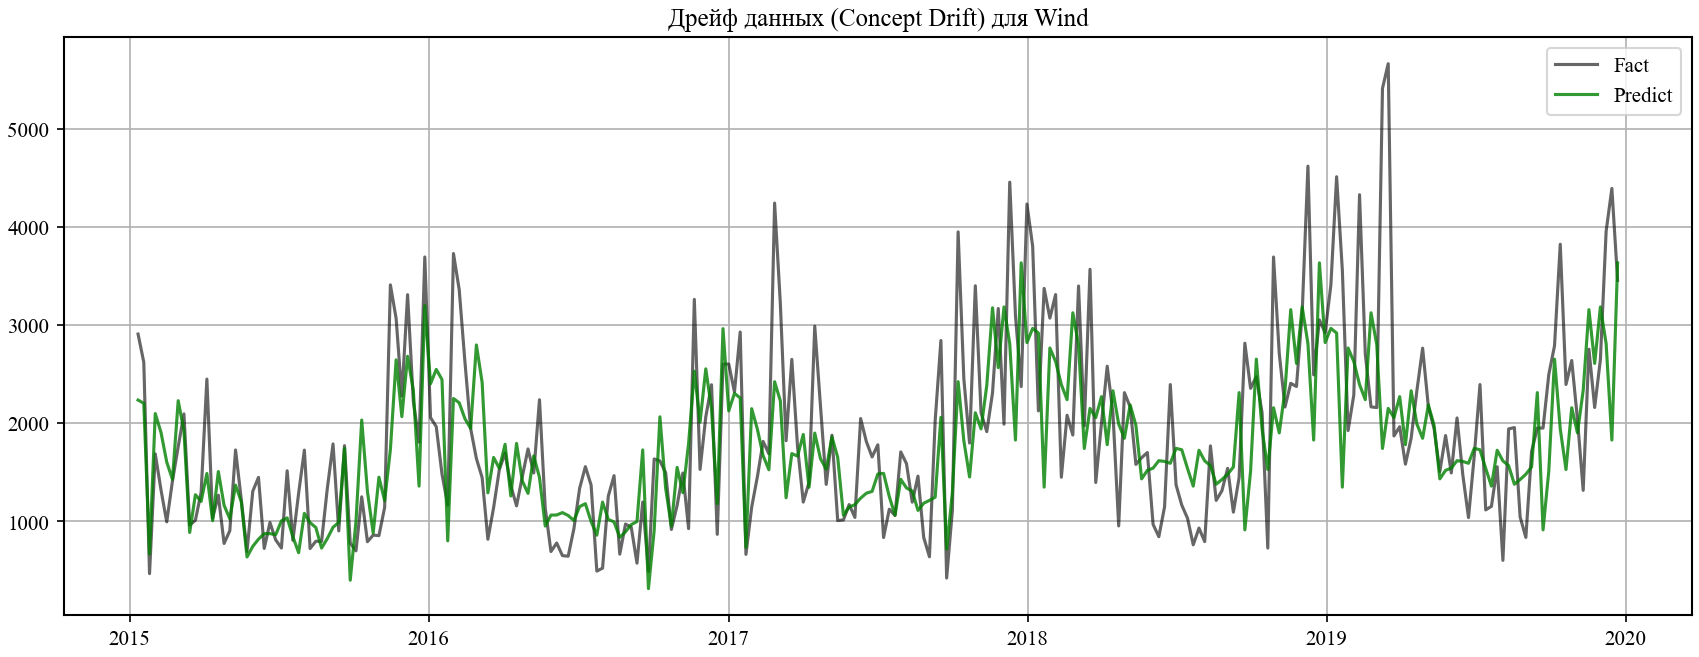

Для Wind дрейфа не обнаружено. Ряд стабильный.



C:\Users\Ronkin\AppData\Local\Temp\ipykernel_14980\2393737011.py:29: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  stat, p_value = ks_2samp(ref_window, cur_window)


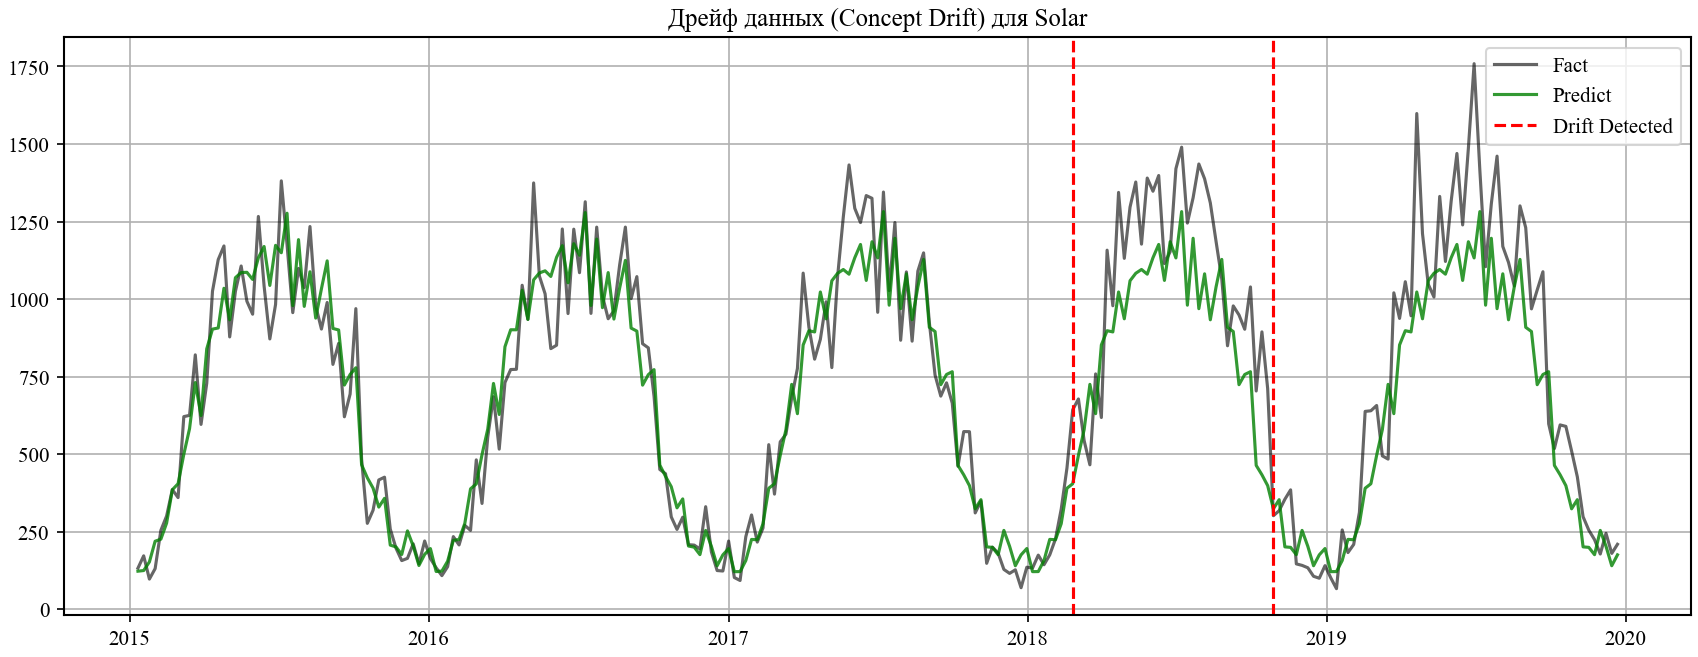

Сегменты для Solar:


,start,end,mean_residual,std_residual,type
0,2015-01-11,2018-02-18,-1.690849,103.226394,Stable
1,2018-02-25,2018-10-21,173.349041,167.702199,Stable
2,2018-10-28,2019-12-22,108.384282,169.160428,Current


In [73]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

# 1. Подготовка остатков (если еще не сделано)
res_df['residual'] = res_df['y'] - res_df['MSTL']

def detect_concept_drift_and_segment(df, uid, window_size=20, threshold=0.05):
    """
    Ищет дрейф данных (Concept Drift) через скользящий KS-тест на остатках.
    Возвращает даты, когда дрейф был обнаружен.
    """
    subset = df[df['unique_id'] == uid].dropna().reset_index(drop=True)
    residuals = subset['residual'].values
    dates = subset['ds'].values
    
    drift_points_idx = []
    
    # Скользящее окно: сравниваем "референсное" окно (начала) с текущим окном
    # Если распределение ошибок меняется -> Дрейф
    ref_window = residuals[:window_size]
    
    # Идем по ряду и проверяем, не изменилось ли распределение ошибки
    for i in range(window_size, len(residuals) - window_size):
        cur_window = residuals[i : i + window_size]
        
        # KS-тест: сравниваем распределение ошибок в начале и сейчас
        stat, p_value = ks_2samp(ref_window, cur_window)
        
        # Если p-value низкий, значит распределения разные -> Дрейф
        if p_value < threshold:
            drift_points_idx.append(i)
            # Важный момент: после обнаружения дрейфа обновляем референсное окно,
            # чтобы искать дрейф уже относительно "новой" реальности
            ref_window = cur_window
            
    # Убираем слишком близкие точки (дрейф длительный, берем только начало)
    clean_drift_idx = []
    last_idx = -window_size
    for idx in drift_points_idx:
        if idx - last_idx > window_size:
            clean_drift_idx.append(idx)
            last_idx = idx
            
    return clean_drift_idx, subset

def create_segments(df, drift_indices):
    """
    Сегментация ряда на основе точек дрейфа.
    Возвращает DataFrame с границами сегментов.
    """
    segments = []
    start_idx = 0
    
    for end_idx in drift_indices:
        segment_data = df.iloc[start_idx:end_idx]
        segments.append({
            'start': segment_data['ds'].min(),
            'end': segment_data['ds'].max(),
            'mean_residual': segment_data['residual'].mean(),
            'std_residual': segment_data['residual'].std(),
            'type': 'Stable'
        })
        start_idx = end_idx
        
    # Последний сегмент
    segment_data = df.iloc[start_idx:]
    segments.append({
        'start': segment_data['ds'].min(),
        'end': segment_data['ds'].max(),
        'mean_residual': segment_data['residual'].mean(),
        'std_residual': segment_data['residual'].std(),
        'type': 'Current'
    })
    
    return pd.DataFrame(segments)

# --- ЗАПУСК АНАЛИЗА ---

print("--- Анализ дрейфа и сегментация ---")

for uid in ts:
    drift_idx, data_subset = detect_concept_drift_and_segment(res_df, uid, window_size=15, threshold=0.01)
    
    # 1. Визуализация места дрейфа
    plt.figure(figsize=(14, 5))
    plt.plot(data_subset['ds'], data_subset['y'], label='Fact', color='black', alpha=0.6)
    plt.plot(data_subset['ds'], data_subset['MSTL'], label='Predict', color='green', alpha=0.8)
    
    # Рисуем вертикальные линии в местах дрейфа
    for idx in drift_idx:
        drift_date = data_subset.iloc[idx]['ds']
        plt.axvline(x=drift_date, color='red', linestyle='--', label='Drift Detected' if idx == drift_idx[0] else "")
        
    plt.title(f'Дрейф данных (Concept Drift) для {uid}')
    plt.legend()
    plt.show()
    
    # 2. Сегментация (таблица с периодами стабильности)
    if drift_idx:
        seg_df = create_segments(data_subset, drift_idx)
        print(f"Сегменты для {uid}:")
        display(seg_df)
    else:
        print(f"Для {uid} дрейфа не обнаружено. Ряд стабильный.\n")